<a href="https://colab.research.google.com/github/brijeshksingh/AIML_Colab_repo/blob/main/House_price_pred_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install catboost
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 3.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

In [5]:
df = pd.read_csv('/content/Week 11_Graded Mini Project_Dataset_houseprice.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.columns

In [ ]:
df.describe()

In [6]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
df.dtypes[ df.dtypes != 'object']

### 1.1	Handling Missing Values: Identify and handle missing values appropriately.

<Axes: >

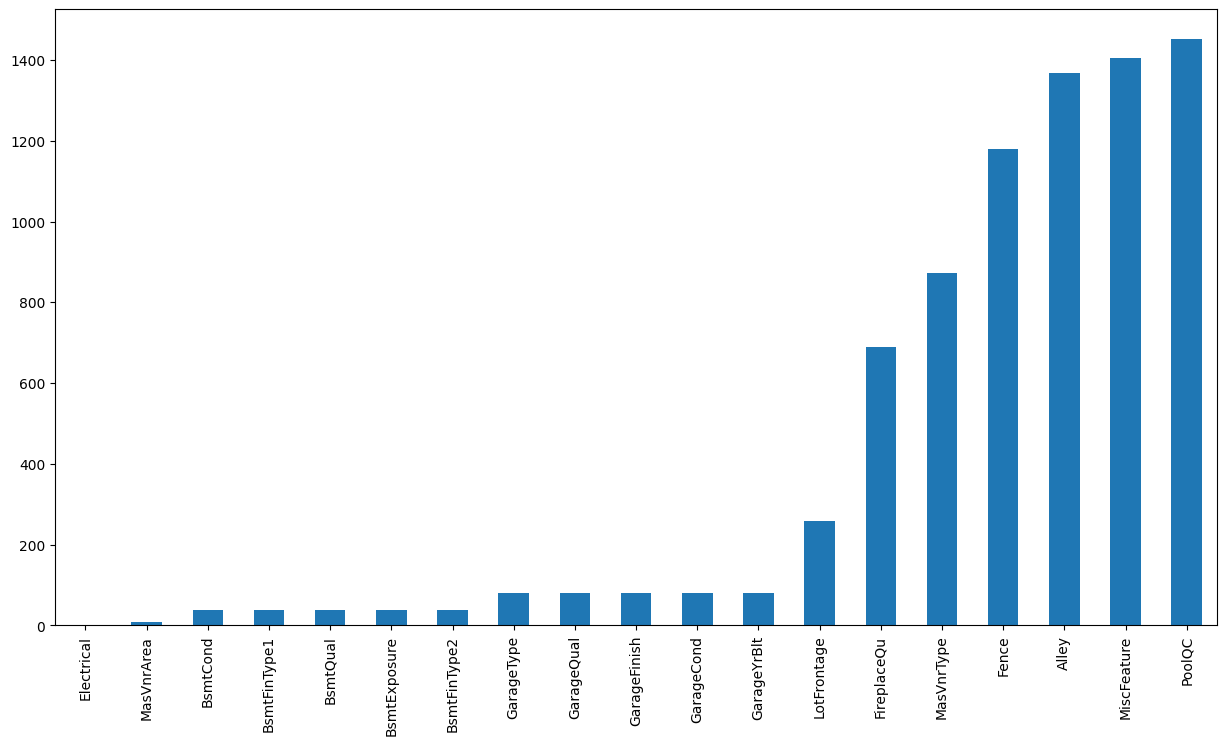

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
plt.figure(figsize=(15, 8))
missing.plot.bar()

In [ ]:
sns.set(rc={'figure.figsize':(15,8)})
sns.displot(df['SalePrice'],kde=True,  bins=20);

In [ ]:
df.isnull().sum()

In [ ]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [ ]:
df.shape

In [ ]:
df.info()

In [8]:
df.LotFrontage  = df.LotFrontage.fillna(df.LotFrontage.mean())

In [ ]:
df.Alley.isnull().sum()

In [9]:
df.Alley = df.drop(columns=['Alley'], inplace=True)

In [ ]:
df.MSZoning.value_counts()

In [10]:
df.MSZoning = df.MSZoning.fillna(df.MSZoning.mode()[0])
df.BsmtCond = df.BsmtCond.fillna(df.BsmtCond.mode()[0])
df.BsmtQual = df.BsmtQual.fillna(df.BsmtQual.mode()[0])
df.FireplaceQu = df.FireplaceQu.fillna(df.FireplaceQu.mode()[0])
df.GarageType = df.GarageType.fillna(df.GarageType.mode()[0])
df.GarageFinish = df.GarageFinish.fillna(df.GarageFinish.mode()[0])
df.GarageQual = df.GarageQual.fillna(df.GarageQual.mode()[0])
df.GarageCond = df.GarageCond.fillna(df.GarageCond.mode()[0])
df.drop(columns=['GarageYrBlt'], axis=1, inplace=True)
df.drop(columns=['PoolQC', 'Fence', 'MiscFeature'], axis=1, inplace=True)

In [ ]:
df.shape

In [11]:
df.drop(columns=['Id'], axis=1, inplace=True)

In [ ]:
df.isnull().sum()

In [12]:
df.MasVnrArea = df.MasVnrArea.fillna(df.MasVnrArea.mode()[0])
df.MasVnrType = df.MasVnrType.fillna(df.MasVnrType.mode()[0])

In [ ]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [13]:
df.BsmtExposure = df.BsmtExposure.fillna(df.BsmtExposure.mode()[0])
df.BsmtFinType1 = df.BsmtFinType1.fillna(df.BsmtFinType1.mode()[0])
df.BsmtFinType2 = df.BsmtFinType2.fillna(df.BsmtFinType2.mode()[0])

<Axes: >

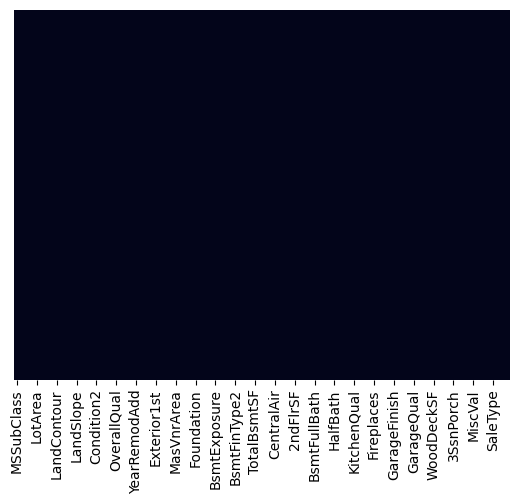

In [14]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False)

In [ ]:
df.isnull().sum()

In [15]:
df.dropna(inplace=True)

In [ ]:
df.shape

In [ ]:
df.head()

### 1.2	Converting Categorical Variables: Encode categorical variables using suitable methods (e.g., one-hot encoding).

In [16]:
categorical_features = df.select_dtypes(include='object').columns
categorical_features

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
len(categorical_features)

In [17]:
main_df = df.copy()
main_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Gd,Attchd,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,BrkFace,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,BrkFace,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


In [ ]:
main_df.shape

In [ ]:
df.shape

In [18]:
final_df = main_df
final_df.shape

(1459, 75)

In [19]:
def category_onehot_multcols(multcolumns):
    df_final=final_df
    i=0
    for fields in multcolumns:


        df1=pd.get_dummies(final_df[fields],drop_first=True)

        final_df.drop([fields],axis=1,inplace=True)
        if i==0:
            df_final=df1.copy()
        else:

            df_final=pd.concat([df_final,df1],axis=1)
        i=i+1


    df_final=pd.concat([final_df,df_final],axis=1)

    return df_final

In [20]:
final_df=category_onehot_multcols(categorical_features)

In [21]:
final_df = final_df.loc[:,~final_df.columns.duplicated()]
print(f"Shape after removing duplicates: {final_df.shape}")

Shape after removing duplicates: (1459, 175)


In [22]:
final_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,FV,RH,RL,RM,Pave,IR2,IR3,Reg,HLS,Low,Lvl,NoSeWa,CulDSac,FR2,FR3,Inside,Mod,Sev,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,MeadowV,Mitchel,NAmes,NPkVill,NWAmes,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker,Feedr,Norm,PosA,PosN,RRAe,RRAn,RRNe,RRNn,2fmCon,Duplex,Twnhs,TwnhsE,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl,Gable,Gambrel,Hip,Mansard,Shed,CompShg,Membran,Metal,Roll,Tar&Grv,WdShake,WdShngl,AsphShn,BrkComm,BrkFace,CBlock,CemntBd,HdBoard,ImStucc,MetalSd,Plywood,Stone,Stucco,VinylSd,Wd Sdng,WdShing,Brk Cmn,CmentBd,Other,Wd Shng,Fa,Gd,TA,Po,PConc,Slab,Wood,Mn,No,BLQ,GLQ,LwQ,Rec,Unf,GasA,GasW,Grav,OthW,Wall,Y,FuseF,FuseP,Mix,SBrkr,Maj2,Min1,Min2,Typ,Attchd,Basment,BuiltIn,CarPort,Detchd,RFn,P,CWD,Con,ConLD,ConLI,ConLw,New,Oth,WD,AdjLand,Alloca,Family,Normal,Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2,548,0,61,0,0,0,0,0,2,2008,208500,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,2,460,298,0,0,0,0,0,0,5,2007,181500,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2,608,0,42,0,0,0,0,0,9,2008,223500,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,T

### 1.3	Normalising Numerical Features: Normalise numerical features to ensure they are on a comparable scale

In [23]:
# Identify numerical columns
numerical_features = final_df.select_dtypes(include=np.number).columns.tolist()

# Exclude the target variable 'SalePrice' if it's in the numerical features
if 'SalePrice' in numerical_features:
    numerical_features.remove('SalePrice')

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical features of the final_df
final_df[numerical_features] = scaler.fit_transform(final_df[numerical_features])

final_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,FV,RH,RL,RM,Pave,IR2,IR3,Reg,HLS,Low,Lvl,NoSeWa,CulDSac,FR2,FR3,Inside,Mod,Sev,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,MeadowV,Mitchel,NAmes,NPkVill,NWAmes,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker,Feedr,Norm,PosA,PosN,RRAe,RRAn,RRNe,RRNn,2fmCon,Duplex,Twnhs,TwnhsE,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl,Gable,Gambrel,Hip,Mansard,Shed,CompShg,Membran,Metal,Roll,Tar&Grv,WdShake,WdShngl,AsphShn,BrkComm,BrkFace,CBlock,CemntBd,HdBoard,ImStucc,MetalSd,Plywood,Stone,Stucco,VinylSd,Wd Sdng,WdShing,Brk Cmn,CmentBd,Other,Wd Shng,Fa,Gd,TA,Po,PConc,Slab,Wood,Mn,No,BLQ,GLQ,LwQ,Rec,Unf,GasA,GasW,Grav,OthW,Wall,Y,FuseF,FuseP,Mix,SBrkr,Maj2,Min1,Min2,Typ,Attchd,Basment,BuiltIn,CarPort,Detchd,RFn,P,CWD,Con,ConLD,ConLI,ConLw,New,Oth,WD,AdjLand,Alloca,Family,Normal,Partial
0,0.073732,-0.229203,-0.207125,0.650852,-0.517424,1.051899,0.879449,0.513594,0.574748,-0.28876,-0.944607,-0.460570,-0.794191,1.162093,-0.120284,0.370055,1.107124,-0.241148,0.790180,1.228641,0.163837,-0.211529,0.912128,-0.951848,0.311842,0.350660,-0.751887,0.215983,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,-1.599030,0.138826,208500,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,-0.871979,0.451876,-0.091909,-0.072372,2.178727,0.157540,-0.428864,-0.571009,1.171304,-0.28876,-0.641330,0.465629,0.256426,-0.794554,-0.120284,-0.482514,-0.820434,3.947370,0.790180,-0.760912,0.163837,-0.211529,-0.318380,0.599824,0.311842,-0.060947,1.625670,-0.704845,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,-0.489318,-0.614137,181500,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,0.073732,-0.092987,0.073401,0.650852,-0.517424,0.985650,0.830993,0.325449,0.092239,-0.28876,-0.301842,-0.314568,-0.628576,1.189587,-0.120284,0.514687,1.107124,-0.241148,0.790180,1.228641,0.163837,-0.211529,-0.318380,0.599824,0.311842,0.631301,-0.751887,-0.070832,-0.359464,-0.11638,-0.270308,-0.068715,-0.087718,0.990298,0.138826,223500,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,F

### 1.4	Outlier Detection: Identify and handle outliers in the dataset.

<Axes: xlabel='SalePrice'>

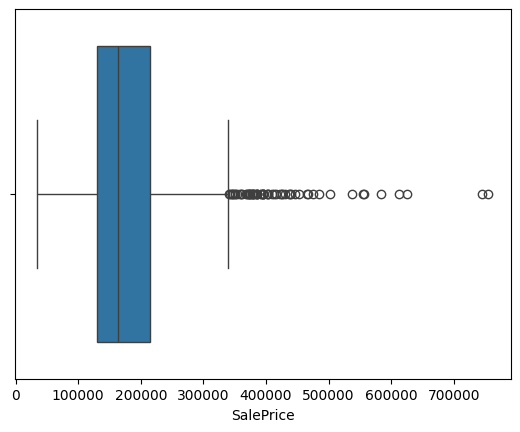

In [24]:
sns.boxplot(x=final_df['SalePrice'])

In [ ]:
sns.boxenplot(data=final_df[numerical_features])
plt.xticks(rotation=90)
plt.show()

In [ ]:
import math

# Identify numerical columns again, as they might have been normalized
numerical_features_for_plot = final_df.select_dtypes(include=np.number).columns.tolist()

# Exclude the target variable 'SalePrice' if it's in the numerical features
if 'SalePrice' in numerical_features_for_plot:
    numerical_features_for_plot.remove('SalePrice')

# Plot boxplots for each numerical feature to visualize outliers
plt.figure(figsize=(20, 15)) # Adjust figure size as needed

for i, col in enumerate(numerical_features_for_plot):
    plt.subplot(math.ceil(len(numerical_features_for_plot)/4), 4, i + 1) # Create subplots
    sns.boxplot(x=final_df[col])
    plt.title(col)

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

In [ ]:
# Identify numerical columns
numerical_cols = final_df.select_dtypes(include=np.number).columns

# Check for normality for each numerical column
for col in numerical_cols:
    # Shapiro-Wilk test for normality
    # p-value < 0.05 suggests the data is NOT normally distributed
    stat, p_value = stats.shapiro(final_df[col])

    alpha = 0.05
    print(f"Column: {col}")
    print(f"Shapiro-Wilk Statistic: {stat:.4f}, P-value: {p_value:.4f}")

    if p_value > alpha:
        print("Conclusion: The data for this column appears to be normally distributed (fail to reject H0)")
    else:
        print("Conclusion: The data for this column does NOT appear to be normally distributed (reject H0)")
    print("-" * 30)

    # Optional: Visualize the distribution using a histogram and QQ plot
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(final_df[col], kde=True)
    plt.title(f'Histogram of {col}')

    # QQ Plot
    plt.subplot(1, 2, 2)
    stats.probplot(final_df[col], dist="norm", plot=plt)
    plt.title(f'QQ Plot of {col}')

    plt.tight_layout()
    plt.show()

Number of outlier rows identified: 439
Shape after removing outliers: (1020, 175)

Outliers have been capped in the original dataframe.


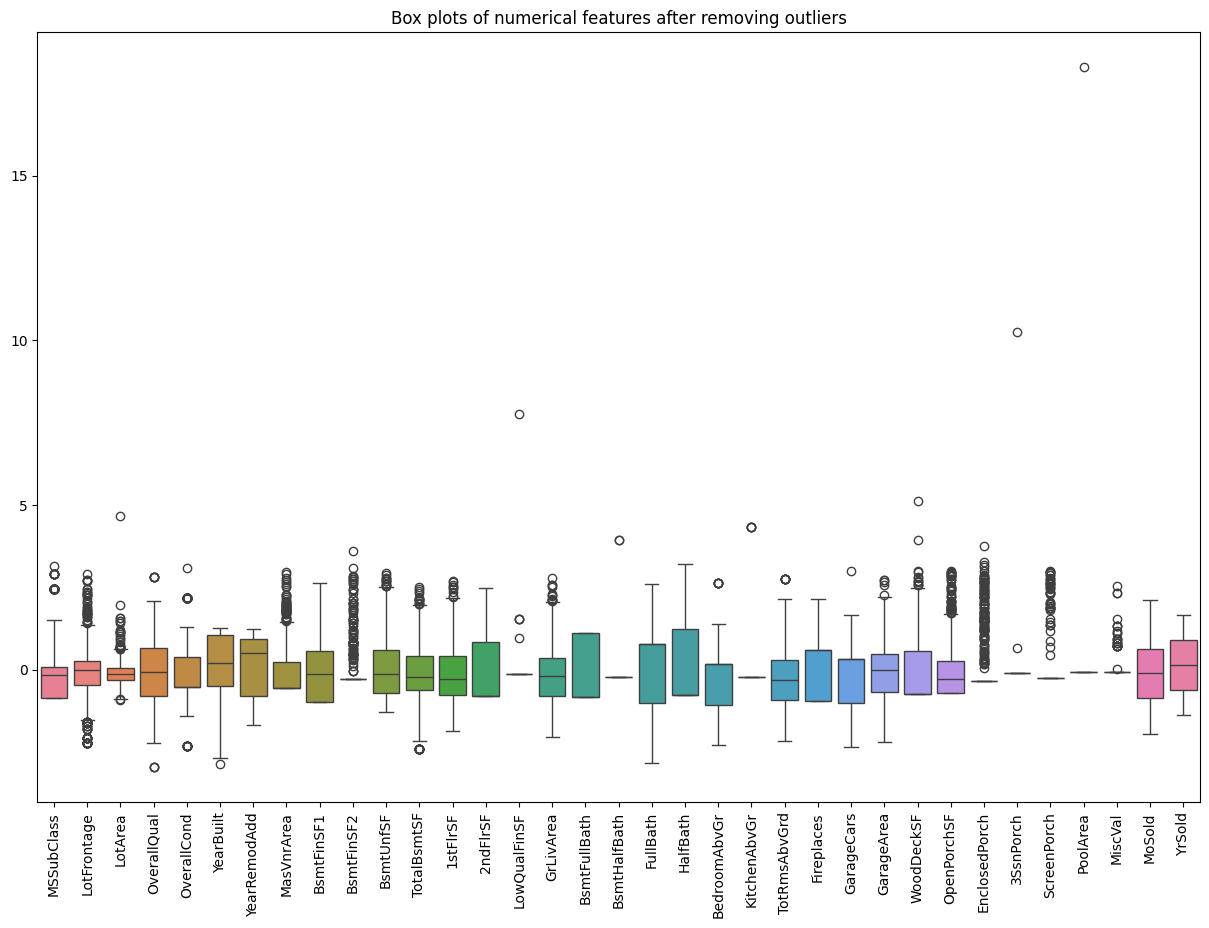

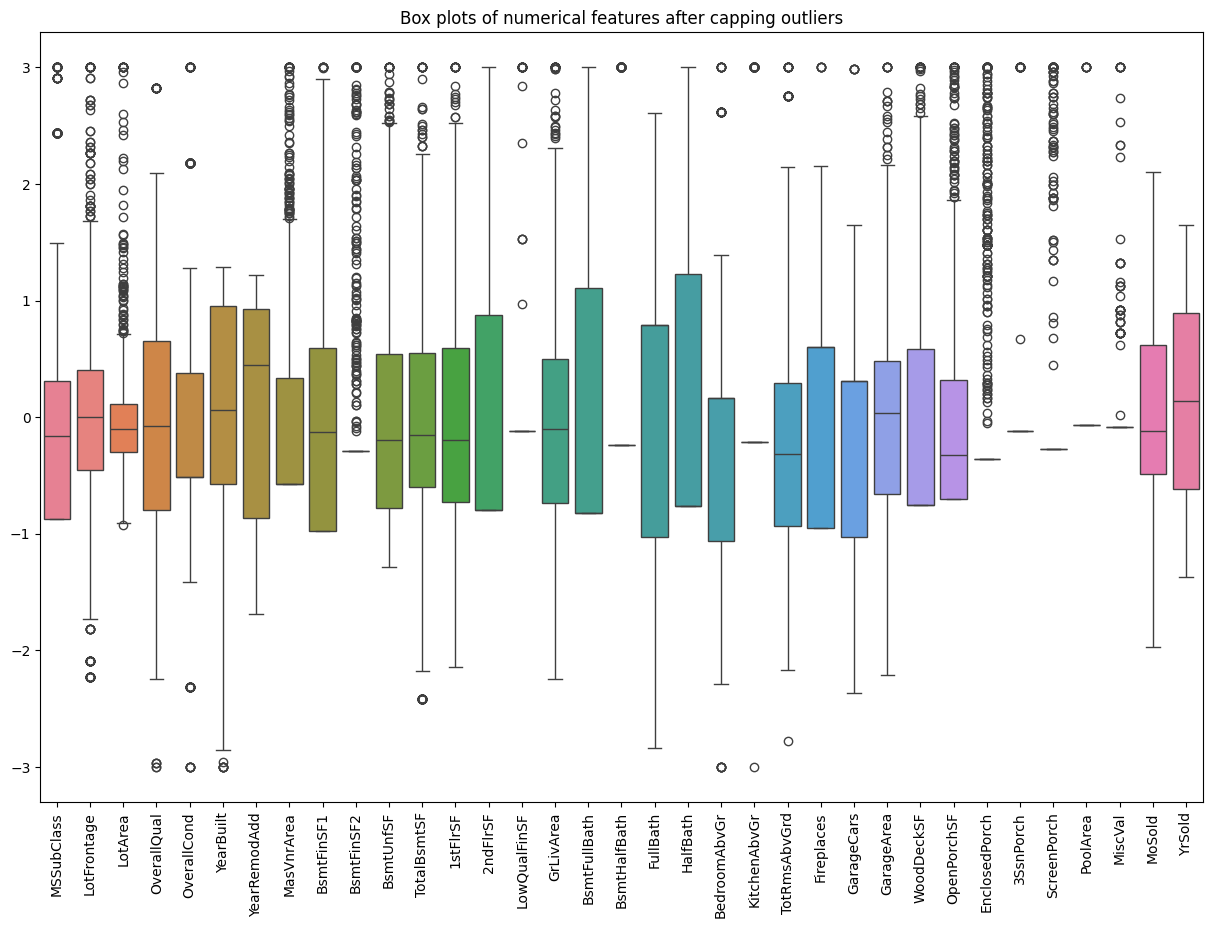

In [25]:
# Use Z-score to detect outliers in numerical features
z_scores = np.abs(stats.zscore(final_df[numerical_features]))
outlier_threshold = 3 # A common threshold

# Identify rows with outliers
outlier_rows = np.where(z_scores > outlier_threshold)[0]

print(f"Number of outlier rows identified: {len(np.unique(outlier_rows))}")

# Option 1: Remove outliers (simplest approach)
df_cleaned = final_df.drop(np.unique(outlier_rows)).reset_index(drop=True)
print(f"Shape after removing outliers: {df_cleaned.shape}")

# Option 2: Cap outliers (replace values beyond a certain threshold)
# we can cap values at the threshold or the mean/median
for col in numerical_features:
    upper_limit = final_df[col].mean() + outlier_threshold * final_df[col].std()
    lower_limit = final_df[col].mean() - outlier_threshold * final_df[col].std()
    final_df[col] = np.where(
        final_df[col] > upper_limit,
        upper_limit,
        np.where(
            final_df[col] < lower_limit,
            lower_limit,
            final_df[col]
        )
    )

print("\nOutliers have been capped in the original dataframe.")
# we can visualize the data before and after handling outliers to see the effect
# For example, using box plots for numerical features
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_cleaned[numerical_features])
plt.title('Box plots of numerical features after removing outliers')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(15, 10))
sns.boxplot(data=final_df[numerical_features])
plt.title('Box plots of numerical features after capping outliers')
plt.xticks(rotation=90)
plt.show()

### 2.1	Creating Interaction Features: Create meaningful interaction features that may help improve model performance

In [26]:
categorical_features1 = final_df.select_dtypes(include=[np.object_])
categorical_features

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [27]:
numerical_features1 = final_df.select_dtypes(include=[np.number])
numerical_features1.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [ ]:
len(numerical_features1.columns)

In [28]:
correlation = numerical_features1.corr()
print(correlation['SalePrice'].sort_values(ascending=False), '\n')

SalePrice        1.000000
OverallQual      0.792018
GrLivArea        0.713548
TotalBsmtSF      0.644325
GarageCars       0.640473
GarageArea       0.629937
1stFlrSF         0.625010
FullBath         0.560881
TotRmsAbvGrd     0.537079
YearBuilt        0.523625
YearRemodAdd     0.507430
Fireplaces       0.468612
MasVnrArea       0.466814
BsmtFinSF1       0.400900
LotArea          0.384331
LotFrontage      0.360766
OpenPorchSF      0.343612
WoodDeckSF       0.328986
2ndFlrSF         0.312390
HalfBath         0.286420
BsmtFullBath     0.228441
BsmtUnfSF        0.210286
BedroomAbvGr     0.176234
ScreenPorch      0.103896
PoolArea         0.093701
3SsnPorch        0.047483
MoSold           0.046380
BsmtHalfBath    -0.015986
YrSold          -0.028907
BsmtFinSF2      -0.036801
MiscVal         -0.040880
LowQualFinSF    -0.046690
OverallCond     -0.080626
MSSubClass      -0.083059
KitchenAbvGr    -0.136606
EnclosedPorch   -0.147104
Name: SalePrice, dtype: float64 



In [ ]:
correlation.shape

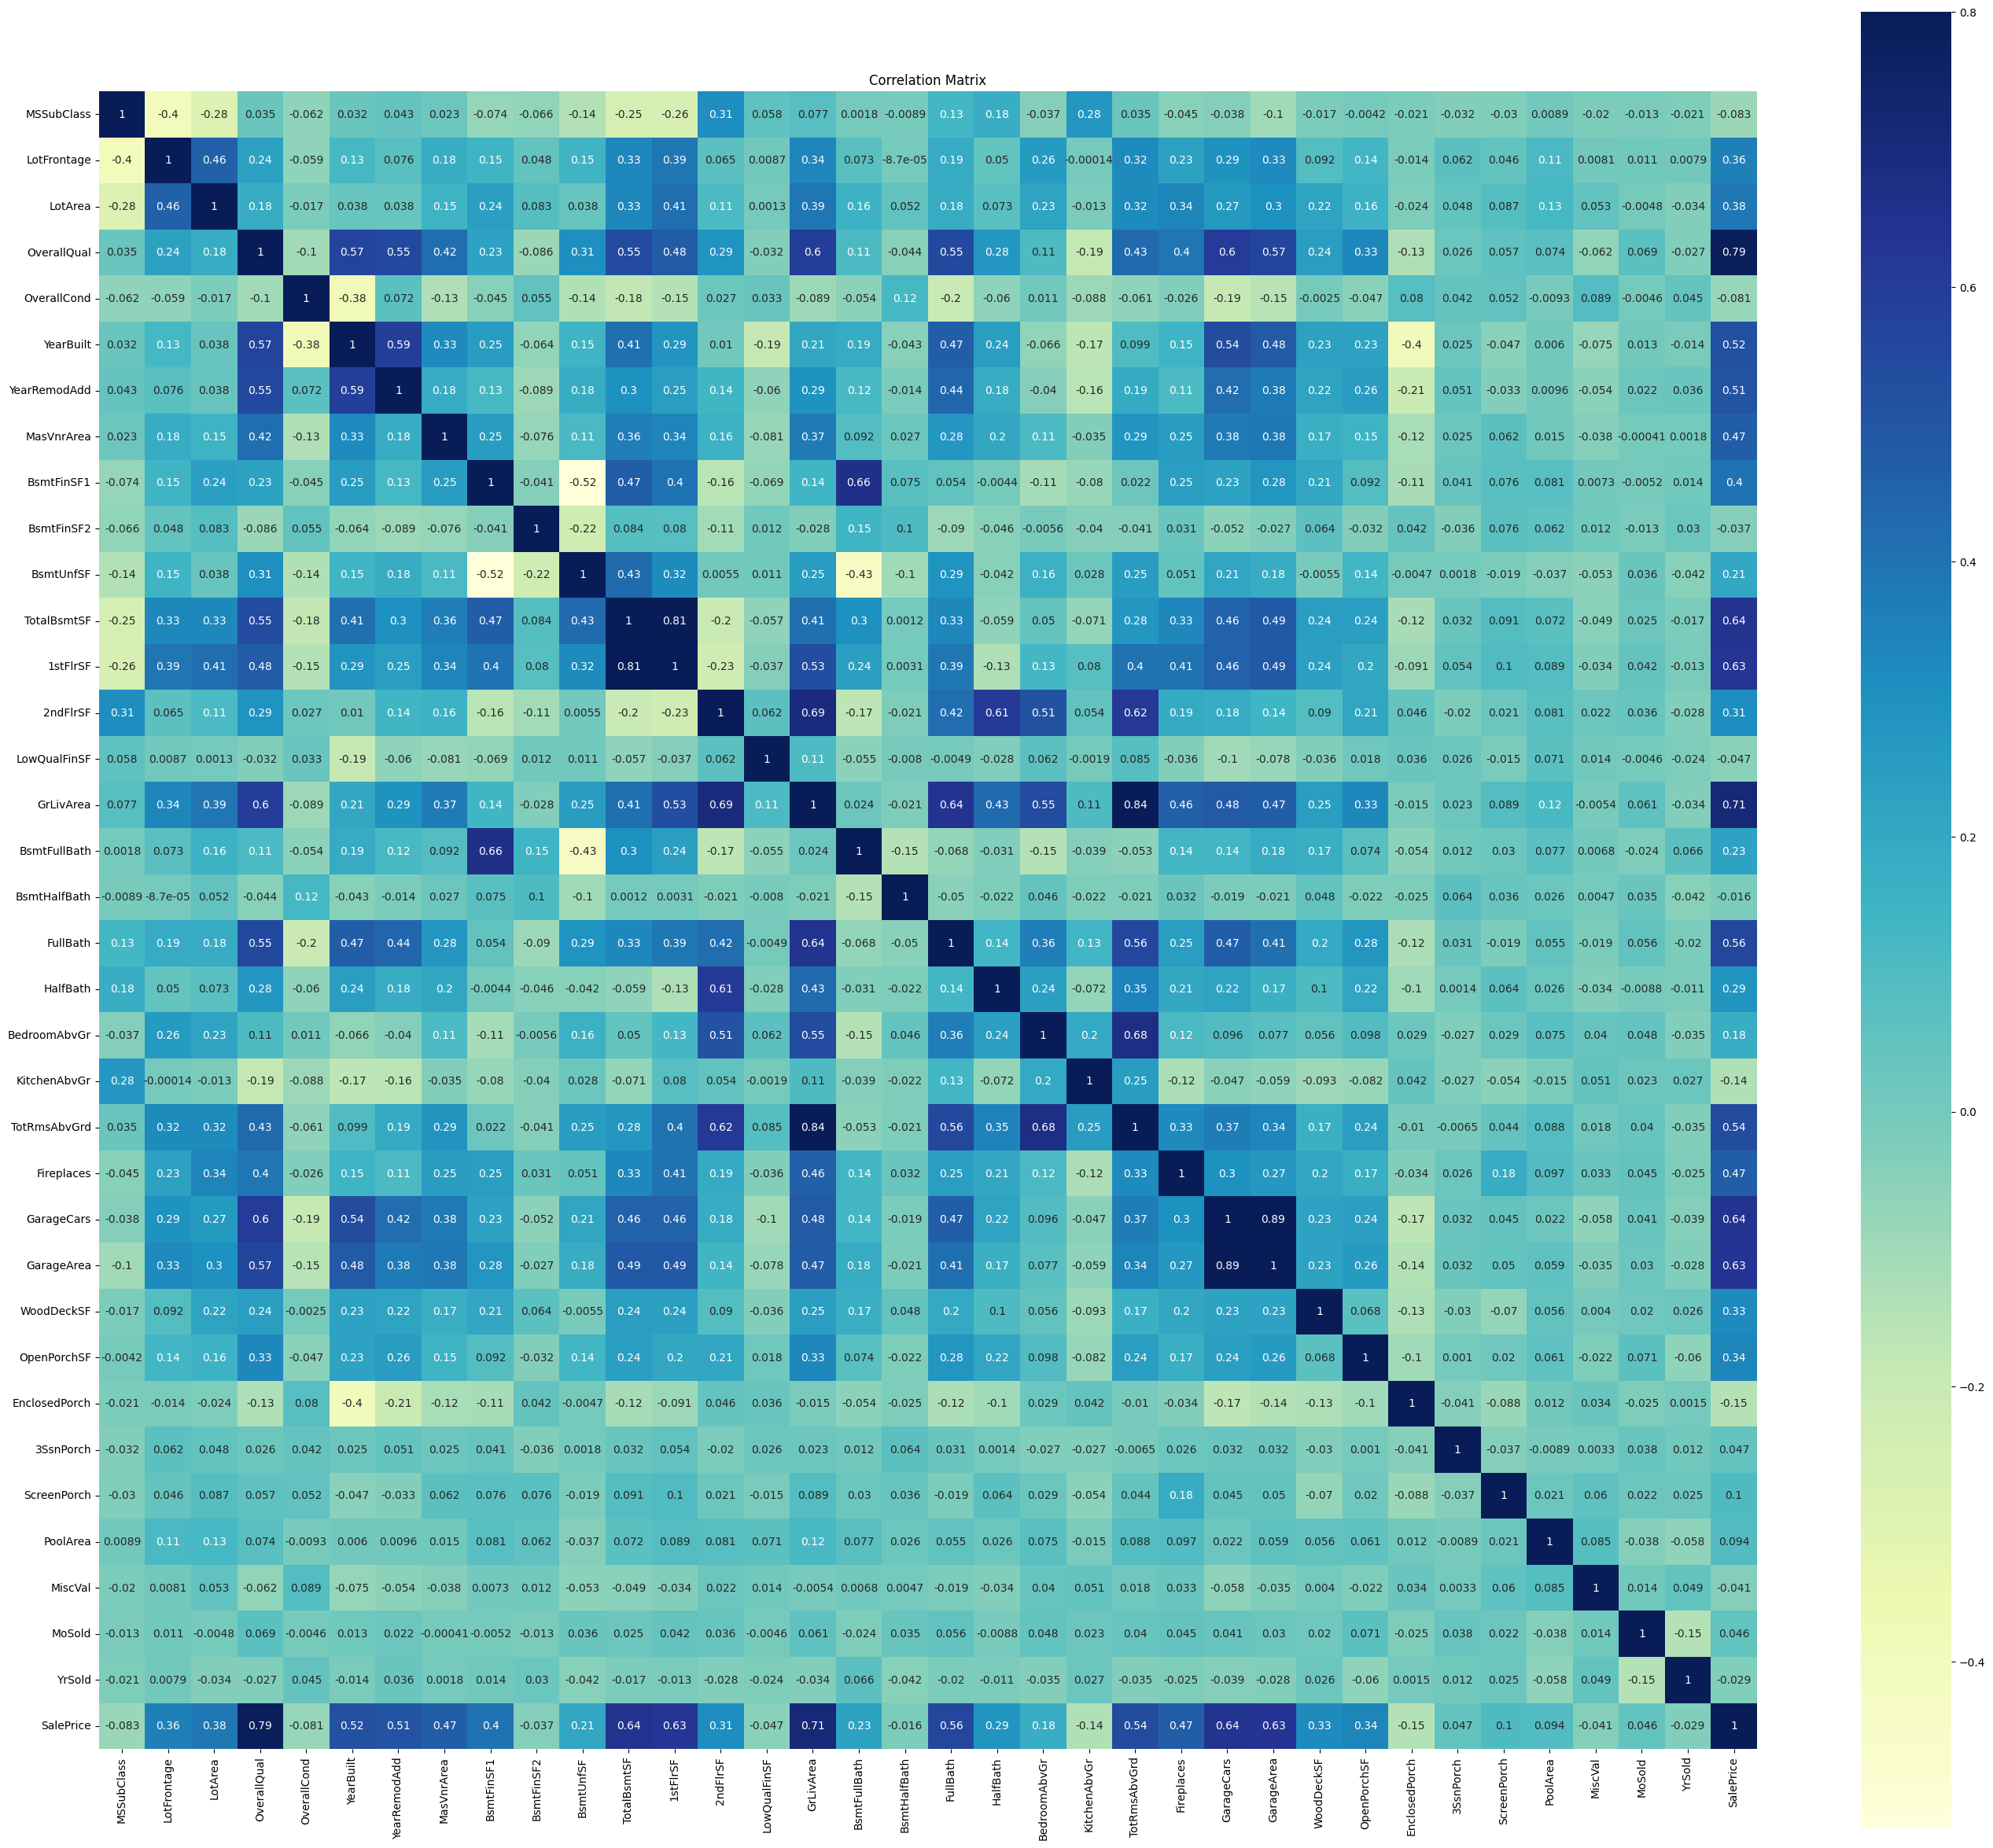

In [29]:
f, ax = plt.subplots(figsize=(34, 30))
plt.title('Correlation Matrix')
sns.heatmap(correlation, vmax=.8, square=True, cmap="YlGnBu", annot=True)
plt.show()

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars',
       'GarageArea', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
       'YearRemodAdd'],
      dtype='object')


<Axes: >

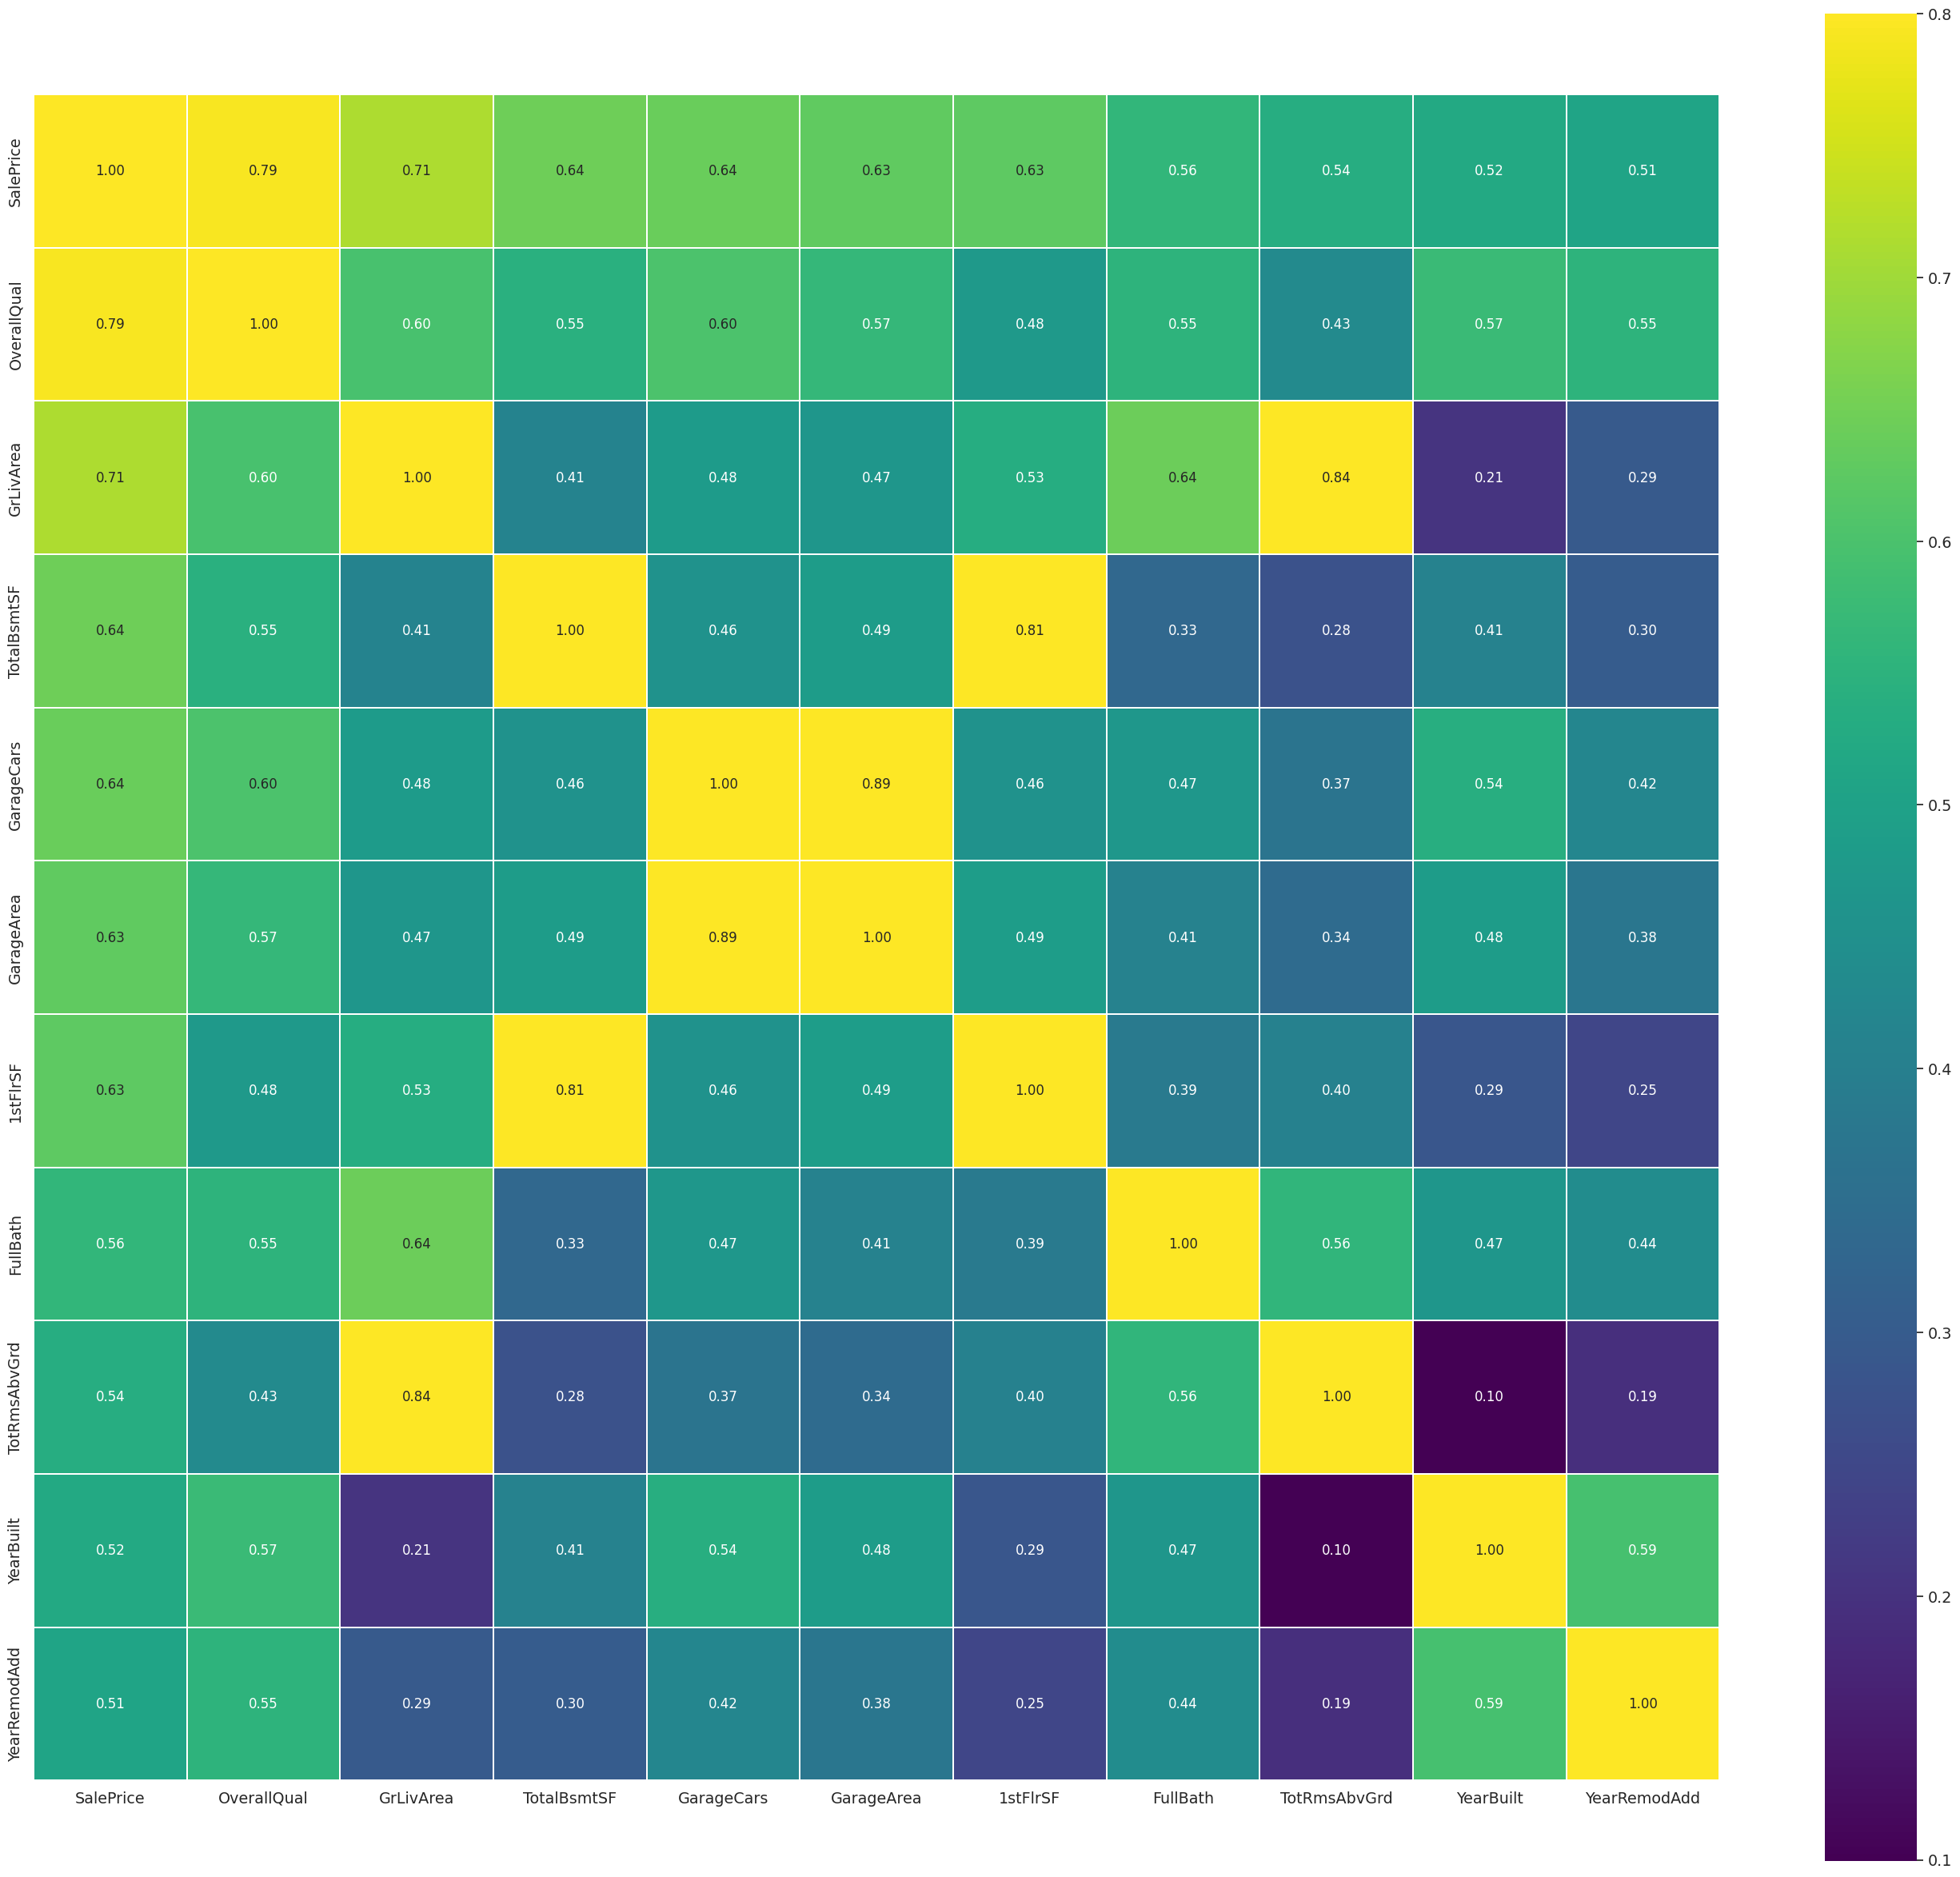

In [30]:
k = 11
cols = correlation.nlargest(k, 'SalePrice')['SalePrice'].index
print(cols)
cm = np.corrcoef(final_df[cols].values.T)
sns.set(font_scale=1.25)
f, ax = plt.subplots(figsize=(34, 30))
sns.heatmap(cm, vmax=0.8, linewidths=.01, cmap="viridis", linecolor='white', annot=True, square=True, fmt='.2f', annot_kws={'size': 12}, yticklabels=cols.values, xticklabels=cols.values)

In [33]:
# Find numerical features excluding 'SalePrice'
numerical_features_without_saleprice = final_df.select_dtypes(include=np.number).columns.tolist()
if 'SalePrice' in numerical_features_without_saleprice:
    numerical_features_without_saleprice.remove('SalePrice')

# Calculate the correlation matrix for independent variables
numerical_cols1 = final_df.select_dtypes(include=[np.number])
X_corr = final_df[numerical_features_without_saleprice].corr()

# Set a threshold for multicollinearity (e.g., absolute correlation greater than 0.7)
multicollinearity_threshold = 0.7

# Find features that are highly correlated with each other
high_corr_pairs = {}
for i in range(len(X_corr.columns)):
    for j in range(i):
        if abs(X_corr.iloc[i, j]) > multicollinearity_threshold:
            colname_i = X_corr.columns[i]
            colname_j = X_corr.columns[j]
            high_corr_pairs[(colname_i, colname_j)] = X_corr.iloc[i, j]

# Print the highly correlated pairs
if high_corr_pairs:
    print("Highly multicollinear features (absolute correlation > {}):".format(multicollinearity_threshold))
    for pair, corr_value in high_corr_pairs.items():
        print(f"  {pair[0]} and {pair[1]}: {corr_value:.4f}")
else:
    print("No highly multicollinear features found above the threshold of {}.".format(multicollinearity_threshold))

# You might want to further investigate these pairs and decide which one(s) to keep
# (e.g., based on domain knowledge, VIF scores, or keeping the one with stronger correlation to the target)

Highly multicollinear features (absolute correlation > 0.7):
  1stFlrSF and TotalBsmtSF: 0.8072
  TotRmsAbvGrd and GrLivArea: 0.8381
  GarageArea and GarageCars: 0.8884


In [35]:
# List features with poor correlation with 'SalePrice'
correlation_with_target = correlation['SalePrice'].sort_values()

# Set a threshold for poor correlation (e.g., absolute correlation less than 0.1 or 0.2)
poor_correlation_threshold = 0.34

poorly_correlated_features = correlation_with_target[abs(correlation_with_target) < poor_correlation_threshold]

print(f"\nFeatures with poor correlation (absolute correlation < {poor_correlation_threshold}) with 'SalePrice':")
poorly_correlated_features


Features with poor correlation (absolute correlation < 0.34) with 'SalePrice':


,SalePrice
EnclosedPorch,-0.147104
KitchenAbvGr,-0.136606
MSSubClass,-0.083059
OverallCond,-0.080626
LowQualFinSF,-0.046690
MiscVal,-0.040880
BsmtFinSF2,-0.036801
YrSold,-0.028907
BsmtHalfBath,-0.015986
MoSold,0.046380


In [36]:
columns_to_drop = ['1stFlrSF', 'TotRmsAbvGrd', 'GarageArea','EnclosedPorch','KitchenAbvGr','MSSubClass','OverallCond','LowQualFinSF','MiscVal','BsmtFinSF2','YrSold','BsmtHalfBath','MoSold','3SsnPorch','PoolArea','ScreenPorch','BedroomAbvGr','BsmtUnfSF','BsmtFullBath','HalfBath','2ndFlrSF','WoodDeckSF'
]
final_df.drop(columns=columns_to_drop, axis=1, inplace=True)
final_df.shape

(1459, 153)

### 2.2	Feature Binning: Bin continuous variables into discrete categories for better interpretability

In [ ]:
# prompt: Bin continuous variables into discrete categories for better interpretability

# Example of binning a continuous variable, e.g., 'LotArea'
# Determine appropriate bins. This can be done based on domain knowledge, quantiles, or visualization.
# Let's use quantiles as an example.
final_df['LotArea_Binned'] = pd.qcut(final_df['LotArea'], q=4, labels=['Small', 'Medium', 'Large', 'Very Large'], duplicates='drop')

# Example of binning another continuous variable, e.g., 'YearBuilt'
# We can create bins for different eras
bins = [1800, 1900, 1950, 1980, 2000, 2020]
labels = ['Pre-1900', '1900-1949', '1950-1979', '1980-1999', '2000+']
final_df['YearBuilt_Binned'] = pd.cut(final_df['YearBuilt'], bins=bins, labels=labels, right=False)

# Drop the original continuous features if you only want to use the binned ones
# final_df.drop(['LotArea', 'YearBuilt'], axis=1, inplace=True)

# Display the new binned columns and their value counts
print("\nValue counts for 'LotArea_Binned':")
print(final_df['LotArea_Binned'].value_counts())

print("\nValue counts for 'YearBuilt_Binned':")
print(final_df['YearBuilt_Binned'].value_counts())

# Remember to handle these new categorical (binned) features by encoding them
# (e.g., using OneHotEncoder or OrdinalEncoder) before using them in a model.
# You would add 'LotArea_Binned' and 'YearBuilt_Binned' to your list of categorical features
# for the next step of feature encoding if you chose to keep them.


In [ ]:
# prompt: create Bin for continuous features into discrete categories for better interpretability

# Define a function to perform binning on a continuous feature
def bin_continuous_feature(df, column, bins, labels=None):
    """
    Bins a continuous feature into discrete categories.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column (str): The name of the column to bin.
        bins (int or sequence of scalars): The criteria to compute the bins.
            Can be an integer, which defines the number of equal-width bins in the range of `column`.
            Can be a sequence of scalars, which defines the bin edges.
        labels (sequence of str, optional): Specifies the labels for the returned bins. Must
            be of the same length as the resulting bins. If False, returns only integer indicators
            of the bins. If None, the labels are the calculated bin intervals. Defaults to None.

    Returns:
        pd.Series: A new Series containing the binned categories.
    """
    if labels is None:
        # If no labels are provided, use the bin intervals
        return pd.cut(df[column], bins=bins)
    else:
        return pd.cut(df[column], bins=bins, labels=labels, include_lowest=True)

# Example usage:
# Bin 'GrLivArea' into 3 equal-width bins
final_df['GrLivArea_Binned_EqualWidth'] = bin_continuous_feature(final_df, 'GrLivArea', bins=3)

# Bin 'GarageCars' based on specific thresholds
# Note: GarageCars is already somewhat discrete, but this demonstrates using custom bins.
# A value of 0 might represent no garage.
bins_garage_cars = [0, 1, 2, 3, final_df['GarageCars'].max()]
labels_garage_cars = ['No Garage', '1 Car', '2 Cars', '3+ Cars']
final_df['GarageCars_Binned'] = bin_continuous_feature(final_df, 'GarageCars', bins=bins_garage_cars, labels=labels_garage_cars)

# Bin 'MasVnrArea' into 3 quantiles
final_df['MasVnrArea_Binned_Quantile'] = pd.qcut(final_df['MasVnrArea'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

# Display the value counts of the new binned columns
print("\nValue counts for 'GrLivArea_Binned_EqualWidth':")
print(final_df['GrLivArea_Binned_EqualWidth'].value_counts())

print("\nValue counts for 'GarageCars_Binned':")
print(final_df['GarageCars_Binned'].value_counts())

print("\nValue counts for 'MasVnrArea_Binned_Quantile':")
print(final_df['MasVnrArea_Binned_Quantile'].value_counts())

# Display the first few rows to see the new columns
print("\nDataFrame with new binned columns:")
print(final_df[['GrLivArea', 'GrLivArea_Binned_EqualWidth', 'GarageCars', 'GarageCars_Binned', 'MasVnrArea', 'MasVnrArea_Binned_Quantile']].head())

# After binning, remember to handle these new categorical (binned) features
# by encoding them (e.g., using OneHotEncoder) before training your model.
# You would add these new binned column names to your list of categorical features
# for the encoding step.